<a href="https://colab.research.google.com/github/keivernunez/dataminingavanzado_austral/blob/main/Teoria_Redes_Neuronales_Convolucionales_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
import requests
import zipfile
import time
import sys
from matplotlib import pyplot as plt
import numpy as np


import os
import requests
import zipfile
import time



from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense

from tensorflow.keras import backend as k
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers


In [ ]:
#Limpio las sesiones que pueden quedar "vivas"
k.clear_session()

In [ ]:
#Levanto drive para poder almacenar los archivos
drive.mount("/content/drive")
contentFolder = "/content/drive/MyDrive/Austral - Data Mining"

Mounted at /content/drive


### **Configuro el ambiente**

In [ ]:
if not os.path.exists(contentFolder):
  os.mkdir(contentFolder)

if not os.path.exists(contentFolder+"/animales"):
  os.mkdir(contentFolder+"/animales")


### **Descargo las imagenes**

In [ ]:
urlEntrenamiento = "https://drive.google.com/u/0/uc?id=1t1qqX3yjvKaLSHP62Ovp6l2RIYYLprdi&export=download&confirm=t&uuid=060d2723-5868-408a-b5c6-cd34ffec3a07"
r = requests.get(urlEntrenamiento)
open("{}/train.zip".format(contentFolder), "wb").write(r.content)

urlTest = "https://drive.google.com/u/0/uc?id=1VXEOECTyFXRkirsSBF-siXF_h3XBUWQ_&export=download&confirm=t&uuid=35cbe7a2-75fc-4b57-a68b-52633b95bddc"
r = requests.get(urlTest)
open("{}/test.zip".format(contentFolder), "wb").write(r.content)

urlValidacion = "https://drive.google.com/u/0/uc?id=1PVJ_8OIEiDftfdyaUqVkoQhDXBrEPEhr&export=download&confirm=t&uuid=3a8e9861-fc48-4b9c-a2d9-b1a6eb0d37c1"
r = requests.get(urlValidacion)
open("{}/validation.zip".format(contentFolder), "wb").write(r.content)

2425

### **Extraigo las imagenes**

In [ ]:
#Extraigo las imágenes a la carpeta de entrenamiento creada
noExiste = True
max_retries = 5
retry_count = 0
while noExiste and retry_count < max_retries:
  if os.path.exists(contentFolder+"/train.zip"):
    with zipfile.ZipFile("{}/train.zip".format(contentFolder), 'r') as zip_ref:
      zip_ref.extractall("{}/animales".format(contentFolder))
    noExiste = False
  else:
    time.sleep(10)
    retry_count += 1
    print(retry_count)
    if retry_count >= 5: break
    if retry_count == max_retries:
        print("Max retries reached. Could not find train.zip")

BadZipFile: File is not a zip file

In [ ]:
#Extraigo las imágenes a la carpeta de entrenamiento creada
noExiste = True
max_retries = 10
retry_count = 0
while noExiste and retry_count < max_retries:
  if os.path.exists(contentFolder+"/test.zip"):
    with zipfile.ZipFile("{}/test.zip".format(contentFolder), 'r') as zip_ref:
      zip_ref.extractall("{}/animales".format(contentFolder))
    noExiste = False
  else:
    time.sleep(10)
    retry_count += 1

    if retry_count == max_retries:
        print("Max retries reached. Could not find test.zip")

In [ ]:
#Extraigo las imágenes a la carpeta de entrenamiento creada
noExiste = True
max_retries = 10
retry_count = 0
while noExiste and retry_count < max_retries:
  if os.path.exists(contentFolder+"/validation.zip"):
    with zipfile.ZipFile("{}/validation.zip".format(contentFolder), 'r') as zip_ref:
      zip_ref.extractall("{}/animales".format(contentFolder))
    noExiste = False
  else:
    time.sleep(10)
    retry_count += 1

    if retry_count == max_retries:
        print("Max retries reached. Could not find validation.zip")

In [ ]:
#Borro los archivos .zip
noExiste = True
max_retries = 10
retry_count = 0
while noExiste and retry_count < max_retries:
    if os.path.exists(contentFolder+"/animales/train"):
        os.remove(contentFolder+"/train.zip")
        noExiste = False
    else:
        time.sleep(10)
        retry_count += 1

    if retry_count == max_retries:
        print("Max retries reached. Could not remove train.zip")

In [ ]:
#Borro los archivos .zip
noExiste = True
max_retries = 10
retry_count = 0
while noExiste:
  if os.path.exists(contentFolder+"/animales/test"):
    os.remove(contentFolder+"/test.zip")
    noExiste = False
  else:
    time.sleep(10)
    retry_count += 1

    if retry_count == max_retries:
        print("Max retries reached. Could not remove test.zip")

In [ ]:
#Borro los archivos .zip
noExiste = True
max_retries = 10
retry_count = 0
while noExiste:
  if os.path.exists(contentFolder+"/animales/validation"):
    os.remove(contentFolder+"/validation.zip")
    noExiste = False
  else:
    time.sleep(10)
    retry_count += 1

    if retry_count == max_retries:
        print("Max retries reached. Could not remove validation.zip")

### **Armo los Generadores de imágenes**
Los generadores son buenos "aliados" ya que nos permiten trabajar con batches de datos y no llevar toda la data a memoria.

In [ ]:
train = "{}/animales/train".format(contentFolder)
test = "{}/animales/test".format(contentFolder)
validation = "{}/animales/validation".format(contentFolder)
modelo = "{}/animales/modelo".format(contentFolder)



In [ ]:
#Defino el batch de imágenes con los que estaré armando los generadores (tengan en cuenta que cada uno de los batches estaremos
#actualizando los pesos)

batch_size = 16

#Definimos alto y ancho de las fotos. Recuerden que la capa de entrada estará definida por el input de los datos
#(En este caso serán 150 x 150 x 3)
height, width = 150, 150
#Cantidad de épocas o ciclos por los que pasarán todas las imágenes
epochs = 50

#Learning Rate
lr = 0.0004

#ImageDataGenerator nos permite trabajar con data Augmentation, esto sirve mucho cuando la cantidad de imágenes no es suficiente y por tal motivo
#Se tiene que utilizar las mismas imágenes pero "transformadas" (usando zoom, rotando las imágenes, etc), para no generar overfitting en las imagenes.
train_datagen = ImageDataGenerator(
        rescale=1./255,  #estandarizo los pixeles de las imagenes dividiendolo por 255, entonces los valores de los pixeles terminan siendo entre 0 y 1.
        shear_range=0.2, #recortar las imagenes de acuerdo al angulo definido.  me aseguro que las imagenes tengan la misma orientacion siempre.
        zoom_range=0.2,  #aplicar zoom in o zoom out por 20%
        validation_split=0.2, #Divide la base de entrenamiento en entrenamiento (80%) y validación (20%)
        horizontal_flip=True)


#lee la carpeta en donde se encuentra la data de Train. Tengan en cuenta que cada carpeta las tomará como un target diferente
#En nuestro caso es un target binario (Dos carpetas, cats y dogs)
#Por tal motivo el class_mode es binary, si hubiera más de una categoría, se debería usar categorical
train_generator = train_datagen.flow_from_directory( #flow_from_directory es un método de ImageDataGenerator, se usa para leer imágenes desde un directorio y generar batches de imagenes
        train,  # this is the target directory
        target_size=(height, width),  # all images will be resized to 150x150
        batch_size=batch_size,
        subset="training",
        class_mode='binary')  # since we use binary_crossentropy loss, we need binary labels

val_generator = train_datagen.flow_from_directory(
        train,  # this is the target directory
        target_size=(height, width),  # all images will be resized to 150x150
        batch_size=batch_size,
        subset="validation",
        class_mode='binary')  # since we use binary_crossentropy loss, we need binary labels


#Para la data de testing sólo se realiza el rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
        test,
        target_size=(height, width),
        batch_size=batch_size,
        class_mode='binary')

clases = {
    0 : "cat",
    1: "dog"
}

Found 12000 images belonging to 2 classes.
Found 3000 images belonging to 2 classes.
Found 7500 images belonging to 2 classes.


### **Visualizamos las imágenes**

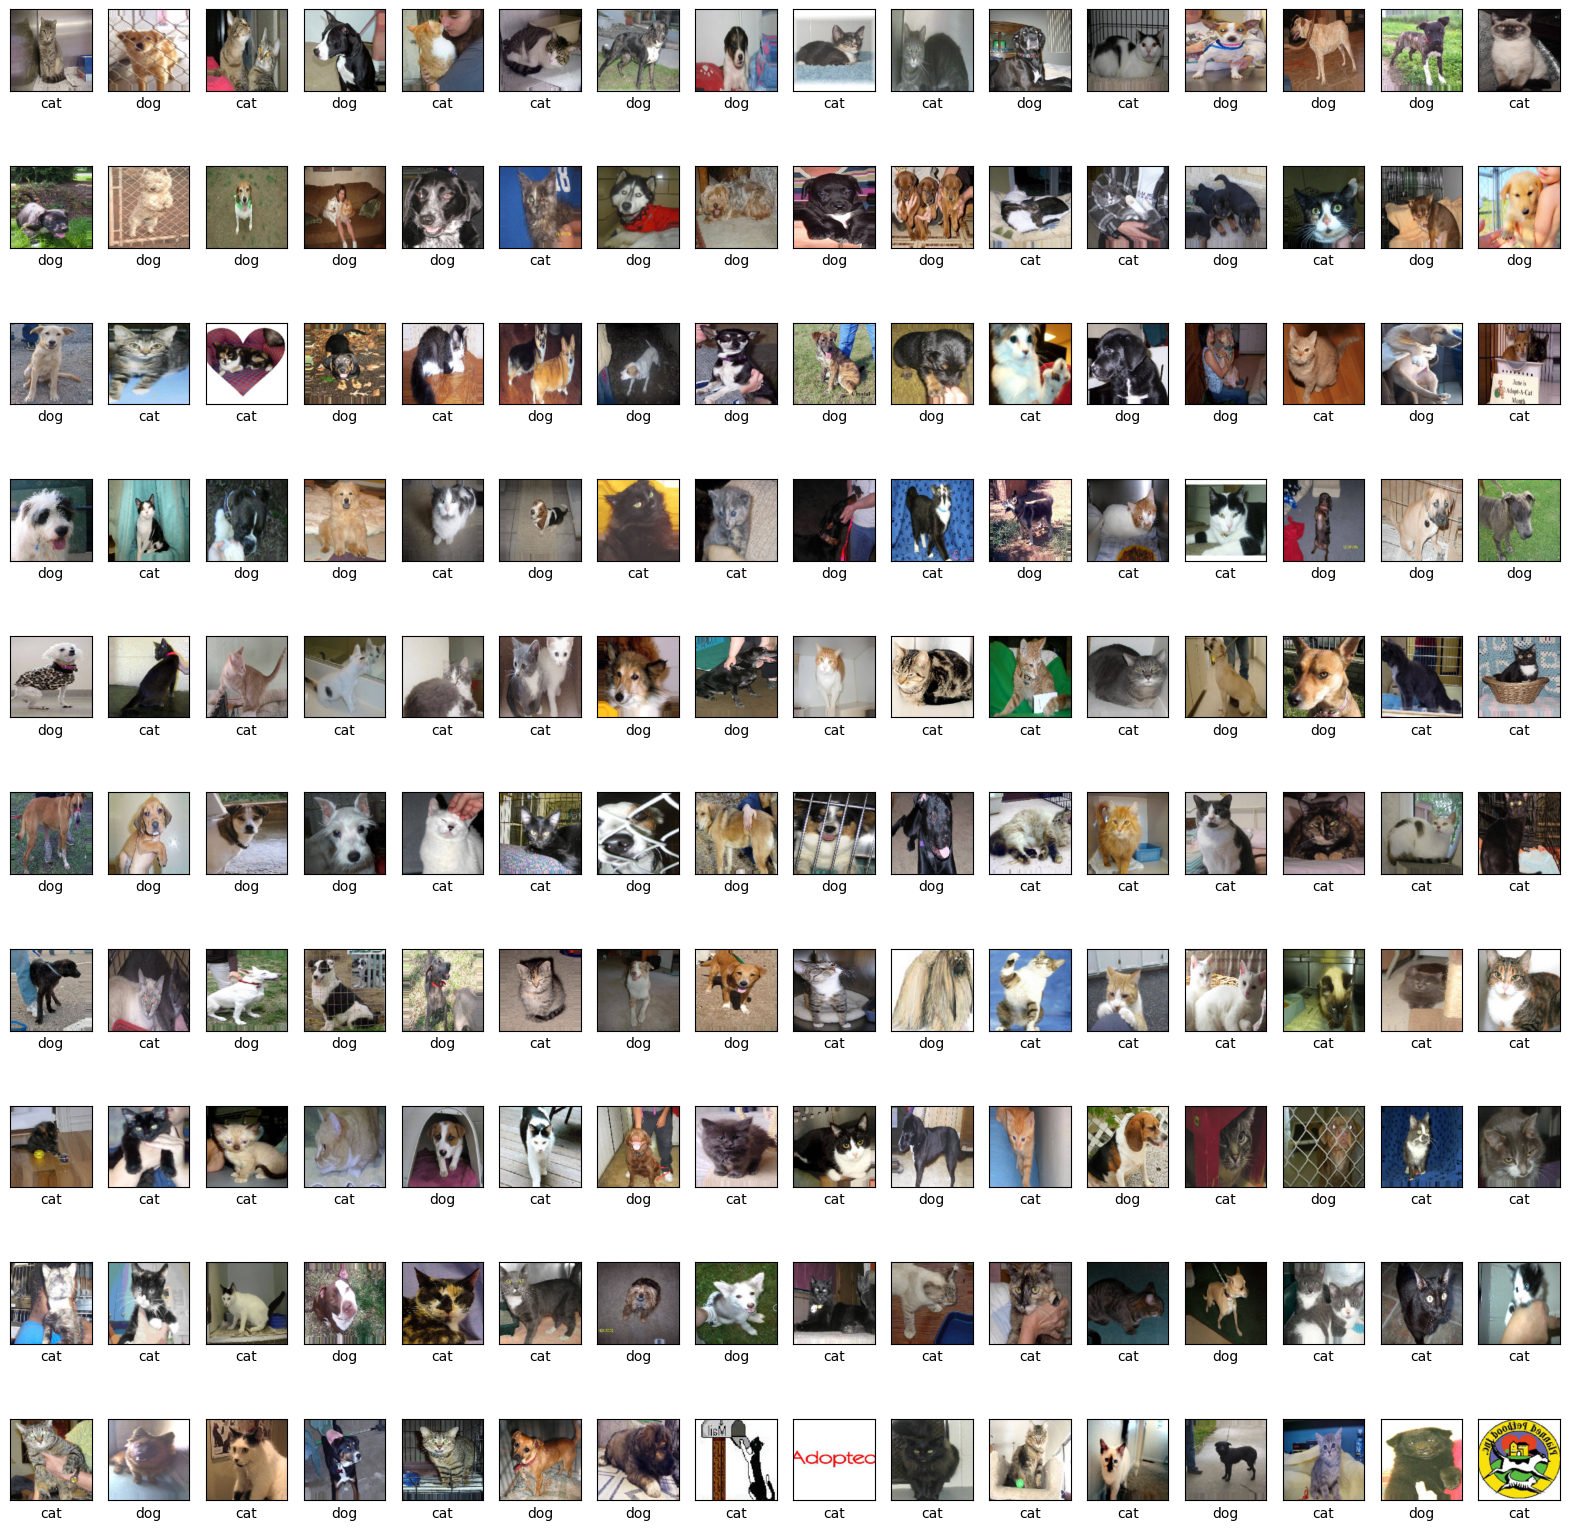

In [ ]:
plt.figure(figsize=(20,20))
cantidadBatches = 10 #son las 10 filas
i = 0
for indice in range(cantidadBatches):
    img, label = train_generator.next() #muestra el siguiente batch dentro del train_generator con las imágenes y la etiqueta

    imageIndexes = img.shape[0]
    for imageIndex in range(0,imageIndexes):
      plt.subplot(cantidadBatches, imageIndexes, (indice)*imageIndexes+imageIndex+1) #va mostrando las imagenes una por una
      plt.xticks([])
      plt.yticks([])
      plt.grid(False)
      plt.imshow(img[imageIndex], cmap=plt.cm.binary)
      plt.xlabel(clases[label[imageIndex]])


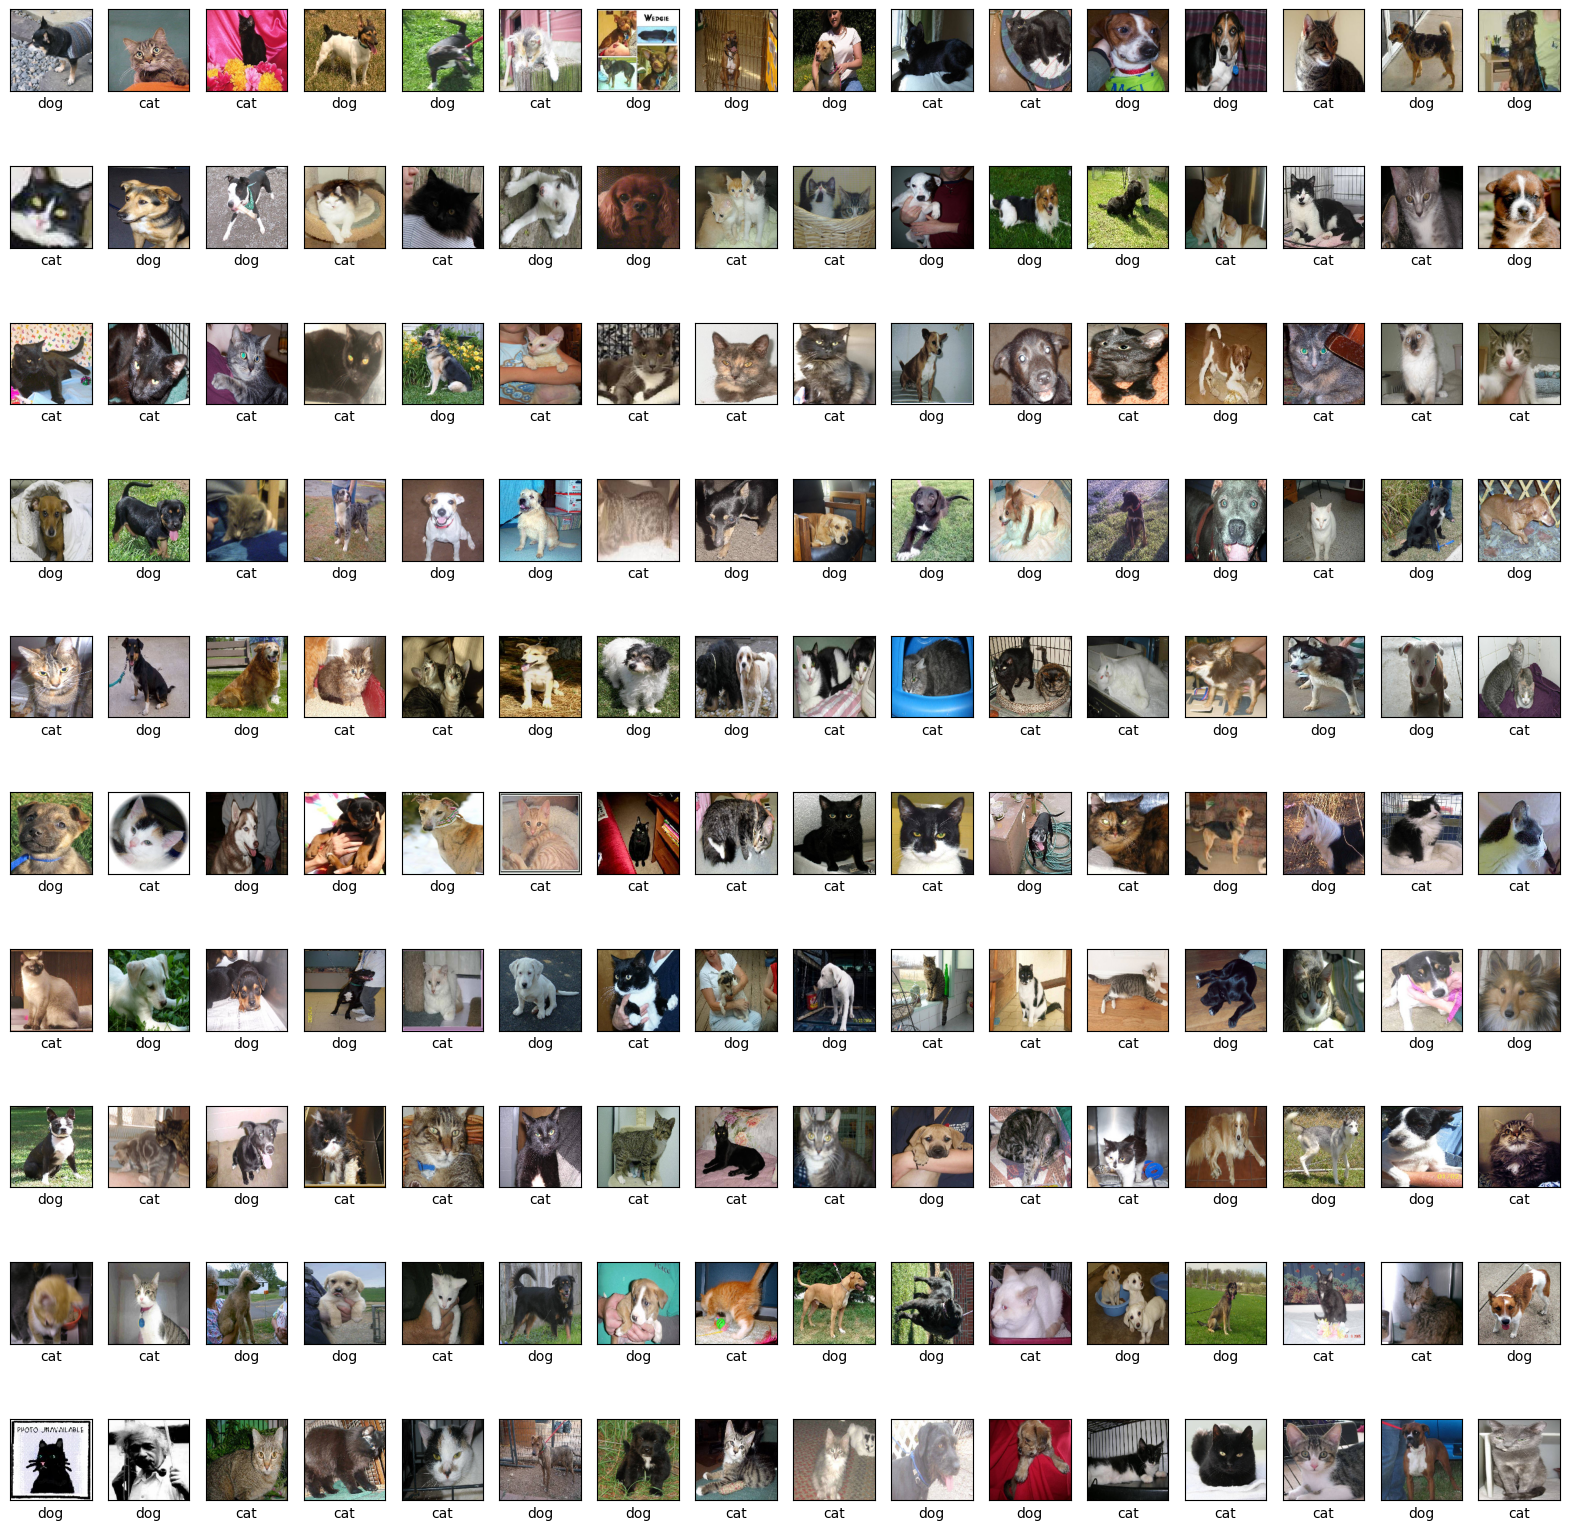

In [ ]:
plt.figure(figsize=(20,20))
cantidadBatches = 10
i = 0
for indice in range(cantidadBatches):
    img, label = test_generator.next()

    imageIndexes = img.shape[0]
    for imageIndex in range(0,imageIndexes):
      plt.subplot(cantidadBatches, imageIndexes, (indice)*imageIndexes+imageIndex+1)
      plt.xticks([])
      plt.yticks([])
      plt.grid(False)
      plt.imshow(img[imageIndex], cmap=plt.cm.binary)
      plt.xlabel(clases[label[imageIndex]])

### **Armado de modelo convolucional**

In [ ]:
#MODELO CONVOLUCIONAL
model = Sequential()
#################################################################
#La neurona de Convolución es la neurona simple
#creo capa convolucional de 32 nucleos o kernels
#cada kernel tendra un tamaño de 3,3
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(height, width, 3)))
#he_uniform implica un peso inicial aleatorio del kernel.
#padding = same implica que la cantidad de output es igual a la cantidad de input.
#input_shape -> como es la primera capa, se le dice cual es ei input de las imágenes, de altura, ancho y cantidad de canales
#Esta capa creará 32 matrices de tamaño 3,3
#En esta capa (en el ejemplo) quedan 32 imágenes de 28x28
#################################################################
#################################################################
#La neurona de max Pooling es la neurona compleja
#Nos ayudará a agrupar la información que nos da la capa de convolución y depender menos de la posición y el tamaño de las cosas
model.add(MaxPooling2D((2, 2)))
#En este caso se pasa la matriz definida en la capa y se obtiene el valor más grande de la matriz, si es una matris de 2x2, se toman los 4 valores y sólo se quedará con el valor mayor
#Luego de esta capa quedarán 32 imágenes de 14x14 (cada imagen se reduce a la mitad)
#################################################################

#################################################################
#Segunda capa de convolución y de Maxpooling -> Cada capa que agregamos, hacemos la imagen mas chica pero cada vez más profunda
model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model.add(MaxPooling2D((2, 2)))
#################################################################

#################################################################
#Comienza la parte de la red neuronal regular o tradicional -> Al principio se usa una capa Flatten para traer todo a una dimensión
model.add(Flatten()) #convierte el output de la capa anterior en un vector de 1 dimension
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform')) #128 neuronas en la capa
model.add(Dense(1, activation='sigmoid')) #output entre 0 y 1
# compile model

opt = optimizers.SGD(lr=0.001, momentum=0.9) #Stochastic Gradient Descent.  momentum ayuda a acelerar la convergencia y estabilizar el camino de la optimización.
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy']) #binery crossentropy penaliza las predicciones mas alejadas del valor real.
#################################################################

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 37, 37, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 18, 18, 128)      0

In [ ]:
history = model.fit(
        train_generator,
        steps_per_epoch= train_generator.n // batch_size, #total de train_generator samples dividido por el tamaño del batch.
        epochs=epochs,
        validation_data=val_generator
)


Epoch 1/50
  3/750 [..............................] - ETA: 1:49 - loss: 0.7004 - accuracy: 0.3542

UnknownError: ignored

### **Grabo el modelo y los pesos**

In [ ]:
#Guardo el modelo y los pesos
model.save(modelo+"/modelo.h5") #guardo el modelo en el formato HDF5
model.save_weights(modelo+"/modelo_weights.h5")

### **Levanto el modelo guardado**

In [ ]:
#Levanto el modelo
new_model = load_model(modelo+"/modelo.h5")

In [ ]:
batch_size = 16
height, width = 150, 150

nuevas_imagenes = ImageDataGenerator(rescale=1./255)
nuevas_imagenes_generator = nuevas_imagenes.flow_from_directory(
        validation,
        target_size=(height, width),
        batch_size=batch_size,
        class_mode='binary')

Found 2500 images belonging to 2 classes.


In [ ]:
a,b = test_generator.next() #a se refiere a la imagen y b, a la etiqueta

In [ ]:
predictions = new_model.predict(test_generator)
predictions

469/469 [==============================] - 36s 77ms/step


array([[0.4845036 ],
       [0.48794654],
       [0.50176185],
       ...,
       [0.4886009 ],
       [0.49958983],
       [0.4982477 ]], dtype=float32)

In [ ]:
predictions = model.predict(a)

1/1 [==============================] - 0s 88ms/step


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(nuevas_imagenes_generator.classes, predictions > 0.5)

ValueError: ignored

In [ ]:
accuracy_score(test_generator.classes, [np.argmax(x) for x in predictions]) #convierte las predicciones en la clase a la que pertenece la imagen


ValueError: ignored